In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# NFW density profile
# rho_DM = 10^4 rho_c / [(r/Rs)(1+r/Rs)^2], beta =1 

# Axion field
# a(r,t)=sqrt(2 rho_DM)/m_a * cos(m_a t)

#COMA DM PARAMETERS : 
rho_0_SI = 1e-22 #kg/m3
Rs_kpc = 340 #kpc 


In [3]:
#natural unit covnersions 
#1 kg/m3 = 4.3101 * 10^-21 GeV^4
# 1 kpc = 1.5639 * 10^41 GeV^-1

rho_0 = rho_0_SI * 4.3 *1e-21 * 1e36 #eV^4
Rs = Rs_kpc * 1.5 *1e41 *1e-9 #ev^-1


In [4]:
r = np.logspace(-2,3,1000)   # 0.01 kpc to 1000 kpc

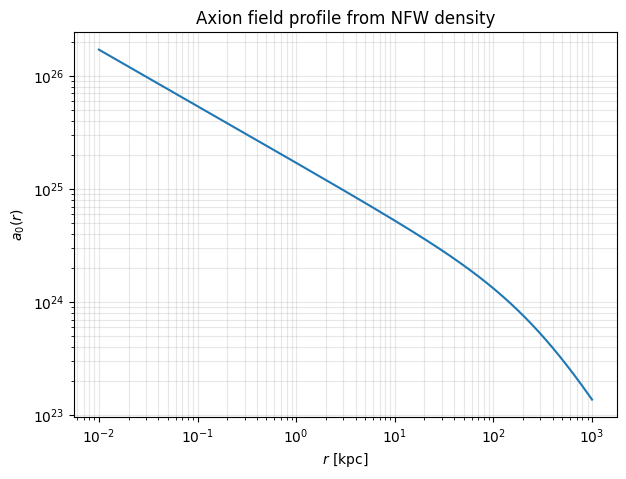

In [5]:
#Mass 
m_a = 1e-27#eV

#Density profile
def rho_DM(r): # NFW density
     return ( rho_0 / ((r/Rs_kpc) * (1 + r/Rs_kpc)**2))

#axion field 
def a(r):
    return np.sqrt(2 * rho_DM(r)) / m_a

# Plot
plt.figure(figsize=(7,5))
plt.loglog(r, a(r))

plt.xlabel(r'$r\ \mathrm{[kpc]}$')
plt.ylabel(r'$a_0(r)$')
plt.title(r'Axion field profile from NFW density')
plt.grid(True, which='both', alpha=0.3)

plt.show()


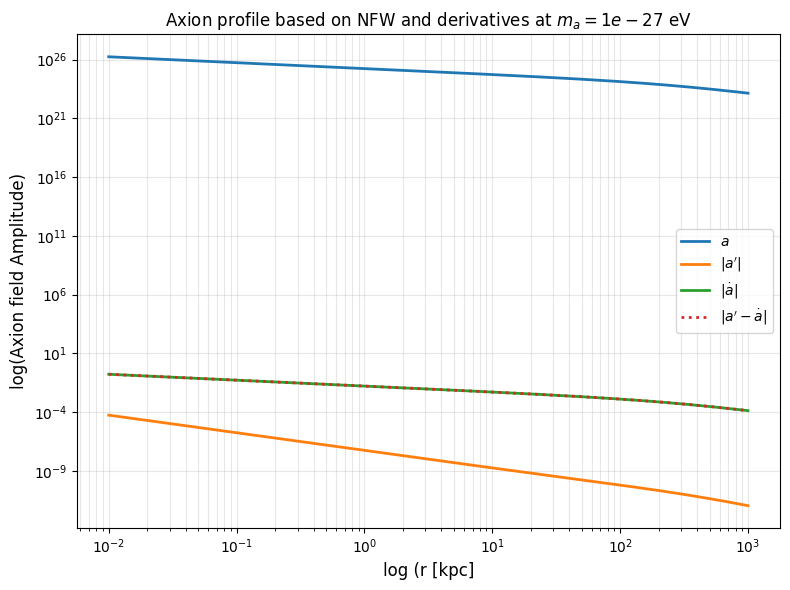

In [6]:
#derivatives of a , in static, i.e taking cos =1 , sin=1
def a_dot(r):
    return ( -1* np.sqrt(2 * rho_0) * (r/Rs_kpc)**-0.5 * (1 + r/Rs_kpc)**-1  )

def a_prime(r):
    return ( ( np.sqrt(2 * rho_0) / ( m_a * Rs) ) * ((-0.5 * (r/Rs_kpc)**-1.5 * (1 + r/Rs_kpc)**-1) + (-1* (r/Rs_kpc)**-0.5 * (1 + r/Rs_kpc)**-2)))

plt.figure(figsize=(8, 6))

plt.loglog(r,a(r),lw=2,label=r'$a$')

plt.loglog(r,np.abs(a_prime(r)),'-',lw=2,label=r'$|a^\prime|$')

plt.loglog(r,np.abs(a_dot(r)),'-',lw=2,label=r'$|\dot a|$')

plt.loglog(r,np.abs(a_prime(r) - a_dot(r)),':',lw=2,label=r'$|a^\prime - \dot a|$')


plt.xlabel('log (r [kpc]', fontsize=12)
plt.ylabel('log(Axion field Amplitude)', fontsize=12)

plt.title(f"Axion profile based on NFW and derivatives at $m_a={m_a:.0e}$ eV")

plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [7]:
#time delay prefactor
g_agg_Normal =  0.66 * 1e-10 #GeV−1
g_agg = g_agg_Normal * 1e-9 #eV-1
wp_SI = 527 #Hz, at the core 
k0_SI = 54 *1e6 #Hz, LOFAR band is 54 MHz 
wp_by_k0 = wp_SI/k0_SI  # i guess then this will be a b dependent factor !! keep watch on it ahead 
#electron density corresponding 
hz_to_eV = 4.135667696e-15
#hence
k0 = k0_SI * hz_to_eV 

value = (g_agg / (4 * k0)) * (wp_by_k0**2)
print("Prefactor =", value)
print("wp/k0 in natural units = ", wp_by_k0)

Prefactor = 7.03684944941243e-24
wp/k0 in natural units =  9.75925925925926e-06


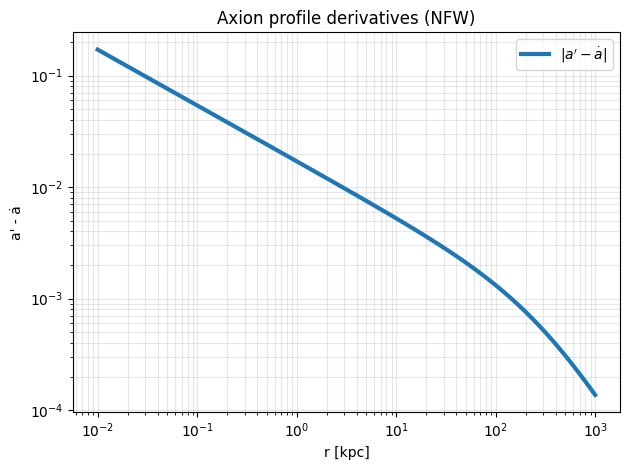

Area under curve = 4.603772501697365e-24


In [9]:
#time delay
#time delay 

def integrand(r):
    return a_prime(r) - a_dot(r)

plt.loglog(
    r, # is in kpc
    integrand(r),  #is in natural units 
    lw=3,
    label=r'$|a^\prime - \dot a|$'
)
 
plt.xlabel('r [kpc]')
plt.ylabel('a\' - ȧ')
plt.title('Axion profile derivatives (NFW)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


from scipy.integrate import simpson
area = value * simpson(integrand(r), x=r) #to convert to natural units 


print("Area under curve =", area)